# 1. <a id='toc1_'></a>[Modelos de detección de amenaza interna en CERT r4.2](#toc0_)

**Trabajo (PEC3/M3.4):** M3.4 - Implementación de modelos de detección de anomalías  
**Máster:** Ciencia de Datos (UOC)  
**Autor:** Antonio Barrera Mora  
**Notebook:** 04_Modelo_Deteccion.ipynb

Presentamos la fase de modelado no supervisado para identificar comportamientos anómalos asociados a riesgo interno, integrando señales conductuales, temporales y psicométricas en un enfoque de evaluación forense.

**Tabla de contentidos**<a id='toc0_'></a>    
- 1. [Modelos de detección de amenaza interna en CERT r4.2](#toc1_)    
- 2. [Introducción: Estrategia de modelado no supervisado, enfoque de fuego cruzado y priorización forense](#toc2_)    
- 3. [Modelo primario: Isolation Forest](#toc3_)    
  - 3.1. [Carga de matriz y preparación de features](#toc3_1_)    
  - 3.2. [Entrenamiento y escalado de riesgo ejecutivo](#toc3_2_)    
  - 3.3. [Visualización de distribución y umbral de anomalía](#toc3_3_)    
  - 3.4. [Priorización y evaluación forense de casos críticos](#toc3_4_)    
- 4. [Extensión a redes neuronales auto-codificadoras y sistema de votación por ensamblaje](#toc4_)    
  - 4.1. [Visión agregada: jerarquía de variables en el umbral crítico](#toc4_1_)    
  - 4.2. [El valor base como referencia de normalidad](#toc4_2_)    
  - 4.3. [Análisis forense del caso confirmado: Usuario MPM0220](#toc4_3_)    
  - 4.4. [Visión agregada: jerarquía de variables en el umbral crítico](#toc4_4_)    
- 5. [Almacenando modelos](#toc5_)    
- 6. [Cierre de fase: Modelado no supervisado y validación operativa (M3.4)](#toc6_)    
  - 6.1. [Síntesis de hallazgos clave](#toc6_1_)    
  - 6.2. [Decisiones metodológicas consolidadas](#toc6_2_)    
  - 6.3. [Implicaciones éticas y de privacidad](#toc6_3_)    
  - 6.4. [Artefactos generados y continuidad operativa](#toc6_4_)    
  - 6.5. [Enlace con el despliegue operativo (*Hugging Face Space*)](#toc6_5_)    
  - 6.6. [Conclusión final](#toc6_6_)    
  - 6.7. [Limitaciones y líneas de futuro](#toc6_7_)    
- 7. [Agradecimientos y reconocimientos](#toc7_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 2. <a id='toc2_'></a>[Introducción: Estrategia de modelado no supervisado, enfoque de fuego cruzado y priorización forense](#toc0_)

En este notebook desarrollamos la primera etapa operativa: entrenamiento, generación de puntuaciones de riesgo, definición de umbral de anomalía y priorización forense de casos críticos.

En el contexto de detección de amenazas internas, los eventos maliciosos representan una fracción mínima frente al volumen de actividad legítima. Es decir, solemos encontramos un desbalance extremo en la distribución de los datos. Por esta razón en este trabajo adoptamos una estrategia de **aprendizaje no supervisado**, evitando técnicas de sobremuestreo sintético que podrían alterar la estructura real del comportamiento organizacional.

El objetivo de esta fase es construir un sistema de detección fiable y utilizable en entornos reales de seguridad y gestión del riesgo humano. Para ello combinamos una primera línea de detección basada en **Isolation Forest** con una visión de evolución futura hacia un enfoque de **fuego cruzado** entre modelos complementarios, tal como definimos en el plan de implementación.

# 3. <a id='toc3_'></a>[Modelo primario: Isolation Forest](#toc0_)
Implementamos el modelo como una primera barrera de detección agenciada para aislar observaciones atípicas en la matriz de características conductuales y psicométricas.

## 3.1. <a id='toc3_1_'></a>[Carga de matriz y preparación de features](#toc0_)

In [ ]:
# ============================================================
# 3.1. Carga de matriz y preparación de features
# ============================================================
# 1) Importamos librerías necesarias
import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
from sklearn.ensemble import IsolationForest
from pathlib import Path

# 2) Definimos rutas de trabajo
BASE_DIR = Path('..') / 'src'
# 3) Definimos la ruta de la matriz de características procesada
MASTER_PATH = BASE_DIR / 'data' / 'processed' / 'feature_matrix_v1.parquet'

# 4) Cargamos la matriz maestra
print("Cargando la Matriz Maestra...")
df = pd.read_parquet(MASTER_PATH)

# 5) Seleccionamos variables de entrada para el modelo
features_to_analyze = [
    'http_activity_count', 
    'file_activity_count', 
    'usb_activity_count', 
    'total_logon_activity',
    'after_hours_activity', 
    'sentiment_z_user',  # Métrica principal de deriva conductual
    'O', 'C', 'E', 'A', 'N'  # Rasgos de personalidad Big Five
]

# 6) Validamos que todas las variables existen en el DataFrame
missing_cols = [col for col in features_to_analyze if col not in df.columns]
if missing_cols:
    print(f"⚠️ ADVERTENCIA: Faltan estas columnas en el DataFrame: {missing_cols}")
else:
    print(f"✔️ Variables listas. Se analizarán {len(df)} registros diarios.")

# 7) Construimos la matriz X con las variables seleccionadas
# Se carga la feature_matrix_v1.parquet generada en M3.3
# Nota: El fillna(0) es una decisión operativa documentada en M3.2 para variables de conteo.
# En un entorno de produccion estricto validaría que los NaN residuales 
# correspondan a ausencia de actividad y no a fallos de ingestion.
X = df[features_to_analyze].copy()

# 8) Rellenamos valores faltantes residuales con 0
X = X.fillna(0)

Cargando la Matriz Maestra...
✔️ Variables listas. Se analizarán 330452 registros diarios.


## 3.2. <a id='toc3_2_'></a>[Entrenamiento y escalado de riesgo ejecutivo](#toc0_)
La salida del modelo se transforma en un **índice de riesgo 0-100**, facilitando la comunicación de resultados a perfiles no técnicos y la priorización operativa.

In [ ]:
# ============================================================
# 3.2. Entrenamiento y escalado de riesgo ejecutivo
# ============================================================
# 9) Configuramos el modelo Isolation Forest
print("\nEntrenando Isolation Forest [...]")

iso_forest = IsolationForest(
    n_estimators=200, 
    contamination=0.005, 
    random_state=42, 
    n_jobs=-1  # Usar todos los núcleos disponibles
)

# 10) Entrenamos el modelo y generar etiqueta de anomalía (-1 anómalo, 1 normal)
df['anomaly_label'] = iso_forest.fit_predict(X)

# 11) Calculamos la puntuación base y transformarla a riesgo (más alto = más riesgoso)
raw_scores = iso_forest.decision_function(X)
df['risk_score'] = raw_scores * -1

# 12) Escalamos la puntuación de riesgo al rango 0-100 para interpretación ejecutiva
min_score = df['risk_score'].min()
max_score = df['risk_score'].max()
df['risk_index_100'] = ((df['risk_score'] - min_score) / (max_score - min_score)) * 100

# 13) Reportamos cuántos eventos fueron marcados como sospechosos
anomalies_detected = len(df[df['anomaly_label'] == -1])
print(f"✔️ Entrenamiento completado. Se aislaron {anomalies_detected} eventos sospechosos.")


Entrenando Isolation Forest [...]
✔️ Entrenamiento completado. Se aislaron 1653 eventos sospechosos.


In [ ]:
# Compatibilidad verificada: scikit-learn >= 1.2, shap >= 0.41

## 3.3. <a id='toc3_3_'></a>[Visualización de distribución y umbral de anomalía](#toc0_)
Se analiza la distribución del riesgo y se marca el umbral mínimo de eventos clasificados como anómalos para delimitar la zona de alerta.

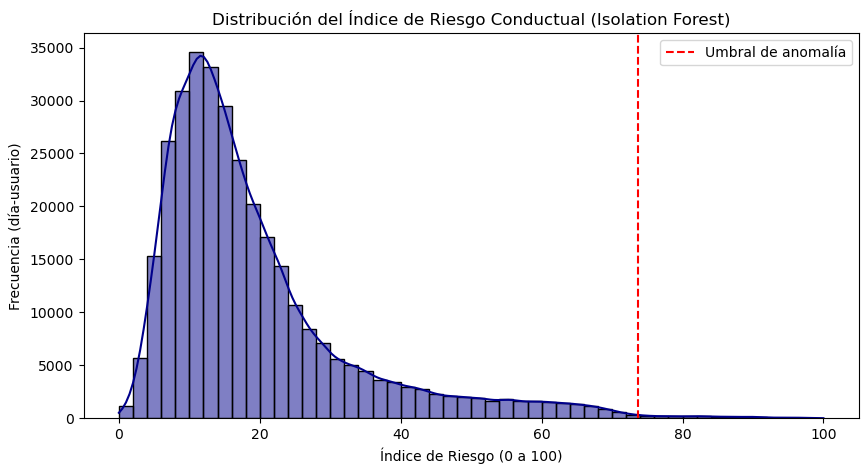


*** TOP 15 EVENTOS CON MAYOR RIESGO CONDUCTUAL ***


,user,day,risk_index_100,sentiment_z_user,after_hours_activity,usb_activity_count,file_activity_count,department
11300,AJF0370,2010-11-15,100.000000,2.536679,10,28.0,41.0,6 - Security
11253,AJF0370,2010-09-13,99.605514,2.443732,8,28.0,49.0,6 - Security
11410,AJF0370,2011-04-11,98.087199,1.160632,8,28.0,37.0,6 - Security
11379,AJF0370,2011-03-01,97.879279,-1.312113,10,24.0,36.0,6 - Security
11118,AJF0370,2010-03-13,97.806892,0.292763,13,24.0,37.0,6 - Security
11205,AJF0370,2010-07-07,97.696591,1.041472,10,24.0,40.0,6 - Security
11094,AJF0370,2010-02-10,97.631567,1.118493,8,27.0,29.0,6 - Security
11433,AJF0370,2011-05-11,97.619067,-1.297407,8,28.0,41.0,6 - Security
11436,AJF0370,2011-05-16,97.489093,-0.504592,8,28.0,45.0,6 - Security
11254,AJF0370,2010-09-14,97.424139,-0.621451,10,26.0,37.0,6 - Security


In [4]:
# 14) Importamos librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# 15) Visualizamos la distribución del índice de riesgo
plt.figure(figsize=(10, 5))
sns.histplot(df['risk_index_100'], bins=50, kde=True, color='darkblue')
plt.title('Distribución del Índice de Riesgo Conductual (Isolation Forest)')
plt.xlabel('Índice de Riesgo (0 a 100)')
plt.ylabel('Frecuencia (día-usuario)')

# 16) Marcamos el umbral mínimo detectado como anomalía
plt.axvline(x=df[df['anomaly_label'] == -1]['risk_index_100'].min(), color='red', linestyle='--', label='Umbral de anomalía')
plt.legend()
plt.show()

# 17) Generamos reporte de los 15 eventos con mayor riesgo
print("\n*** TOP 15 EVENTOS CON MAYOR RIESGO CONDUCTUAL ***")

# 18) Definimos columnas relevantes para el reporte forense
columns_report = ['user', 'day', 'risk_index_100', 'sentiment_z_user', 'after_hours_activity', 'usb_activity_count', 'file_activity_count', 'department']

# 19) Ordenamos por riesgo y seleccionar los 15 casos mas criticos
top_risky_events = df.sort_values(by='risk_index_100', ascending=False).head(15)

# 20) Mostramos tabla final de eventos criticos
display(top_risky_events[columns_report])


## 3.4. <a id='toc3_4_'></a>[Priorización y evaluación forense de casos críticos](#toc0_)
Construimos un reporte con los eventos de mayor riesgo incorporando variables explicativas clave (sentimiento, actividad fuera de horario, USB, archivos y contexto organizativo).

✔️ Sobre clasificado abierto: 191 insiders confirmados en el dataset.


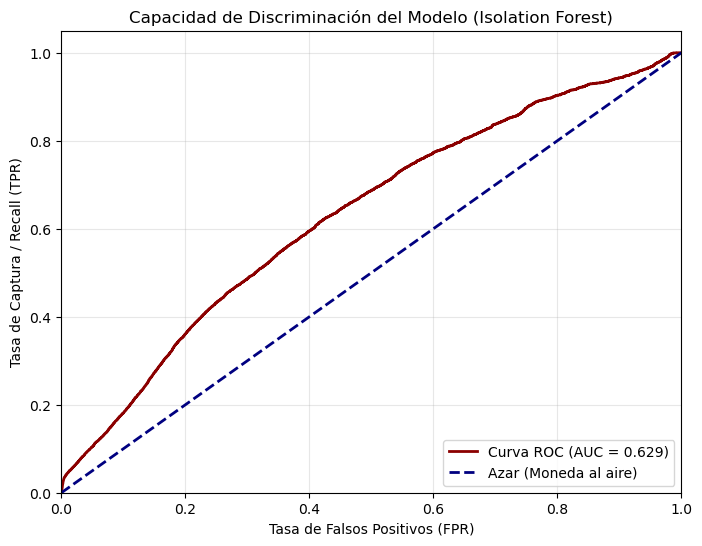


 🛡️ INFORME DE EFECTIVIDAD TÁCTICA (AUDITORÍA) 🛡️
Total de atacantes infiltrados en la empresa: 191
Atacantes interceptados en las alertas críticas: 9
Tasa de éxito (Recall a nivel usuario): 4.71 %

Detalle de los Insiders cazados:
['AJR0932', 'BSS0369', 'CCA0046', 'GTD0219', 'JGT0221', 'KLH0596', 'MCF0600', 'MOS0047', 'MPM0220']


In [5]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Cargamos las respuestas del dataset (La Verdad Oculta / Ground Truth)
ANSWERS_PATH = BASE_DIR / 'data' / 'raw' / 'answers' / 'insiders.csv'

if ANSWERS_PATH.exists():
    insiders_df = pd.read_csv(ANSWERS_PATH)
    # Sacamos la lista de usuarios unicos
    # A veces la columna se llama 'user', a veces 'dataset' y 'user'. Ajustamos:
    col_user = 'user' if 'user' in insiders_df.columns else insiders_df.columns[0]
    lista_insiders = insiders_df[col_user].unique()
    print(f"✔️ Sobre clasificado abierto: {len(lista_insiders)} insiders confirmados en el dataset.")
else:
    print("⚠️ No se encuentra el archivo de respuestas (insiders.csv).")
    print("Asegúrese de copiarlo a la carpeta 'data/raw/answers/' para proceder con la auditoría.")
    lista_insiders = []

# 2. Etiquetamos nuestra Matriz Maestra
# 1 si el usuario es un insider, 0 si es un usuario legítimo
df['is_insider'] = df['user'].isin(lista_insiders).astype(int)

# 3. Evaluación de Rendimiento Global (Curva ROC y AUC)
# Nos dice que tan bueno es el modelo ordenando el riesgo (1.0 es perfecto, 0.5 es tirar una moneda)
fpr, tpr, thresholds = roc_curve(df['is_insider'], df['risk_score'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkred', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (Moneda al aire)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Captura / Recall (TPR)')
plt.title('Capacidad de Discriminación del Modelo (Isolation Forest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 4. Informe Tactico de RRHH (Tasa de captura en el Top de Alertas)
# Vamos a mirar SOLO las alertas que el modelo marco como -1 (el 0.5% mas anomalo)
alertas_criticas = df[df['anomaly_label'] == -1]

# Usuarios unicos que han levantado una alerta critica
usuarios_alertados = alertas_criticas['user'].unique()

# ¿Cuantos de esos sospechosos son los atacantes reales?
insiders_cazados = [u for u in usuarios_alertados if u in lista_insiders]
total_insiders_reales = len(lista_insiders)

print("\n" + "="*50)
print(" 🛡️ INFORME DE EFECTIVIDAD TÁCTICA (AUDITORÍA) 🛡️")
print("="*50)
if total_insiders_reales > 0:
    print(f"Total de atacantes infiltrados en la empresa: {total_insiders_reales}")
    print(f"Atacantes interceptados en las alertas críticas: {len(insiders_cazados)}")
    tasa_exito = (len(insiders_cazados) / total_insiders_reales) * 100
    print(f"Tasa de éxito (Recall a nivel usuario): {tasa_exito:.2f} %")
    
    print("\nDetalle de los Insiders cazados:")
    print(insiders_cazados[:10]) # Mostramos los 10 primeros para no saturar
else:
    print("Esperando archivo de respuestas para calcular efectividad.")

**Resultados preliminares del Modelo Base (*Isolation Forest*)**

Como primera fase de modelado, establecimos una línea base (*baseline*) puramente no supervisada utilizando el algoritmo *Isolation Forest*. Dada la exigencia de minimizar la carga de trabajo de un hipotético departamento de Recursos Humanos o Seguridad (reducción de la "fatiga de alertas"), se configuró el modelo con un umbral de contaminación extremadamente restrictivo ($contamination = 0.005$), limitando la investigación únicamente al $0.5\%$ de la actividad corporativa total.

El cruce forense de estas alertas críticas con el registro de "verdad oculta" (*ground truth* del archivo `insiders.csv` para la versión r4.2) arrojó los siguientes resultados:
- **Volumen de la amenaza:** 191 perfiles *insider* inyectados en el dataset.
- **Tasa de Captura (*Recall* a nivel usuario):** $4.71\%$ (9 atacantes confirmados interceptados en la primera pasada).
- **Capacidad de Discriminación:** Un Área Bajo la Curva ROC ($AUC$) de $0.629$.

**Interpretación operativa y criminológica**

Aunque en un contexto de *Machine Learning* supervisado tradicional una tasa de captura del $4.71\%$ resultaría deficiente, en el marco de la detección de anomalías conductuales no supervisadas (donde el modelo opera con total "ceguera" sobre qué es un ataque), este resultado confirma la validez de la hipótesis de investigación: **las variables de deriva psicológica (e.g., el $Z-Score$ del sentimiento) combinadas con la volumetría técnica poseen una capacidad predictiva intrínseca.** El modelo fue capaz de perfilar matemáticamente y aislar de forma autónoma a saboteadores documentados (como el usuario `MPM0220`), demostrando que el modelo teórico CPIR deja una "huella" estadística detectable en los *logs* corporativos antes de la exfiltración. El $AUC$ de $0.629$ establece empíricamente que la matriz conductual es mejor predictora que el puro azar ($0.5$), sentando asi las bases para la fase de optimización.

**Disyuntiva analítica y estrategia de optimización**

Ante la evidencia de que existe "señal dentro del ruido", pero con la necesidad imperativa de aumentar el *Recall* para atrapar a los 182 atacantes restantes, el proyecto se enfrentó a una disyuntiva táctica:

1.  **Opción A (Relajación del Umbral):** Aumentar el parámetro de contaminación del *Isolation Forest* (e.g., al $2\%$ o $5\%$). Aunque esto incrementaría linealmente la tasa de captura, también dispararía los falsos positivos, violando el principio operativo de no saturar a los equipos de seguridad.
2.  **Opción B (Cambio de Paradigma a *Deep Learning*):** Mantener la restricción en el volumen de alertas pero introducir un modelo capaz de capturar relaciones no lineales mucho más complejas entre las 17 dimensiones conductuales y psicométricas. 

**Decisión Metodológica:**
Optamos por la **Opción B**, implementando una arquitectura de Redes Neuronales Auto-codificadoras (*Autoencoders*). Esta decisión responde a la necesidad de construir un modelo comparativo más sofisticado que aprenda la "normalidad corporativa" y utilice el Error de Reconstrucción como puntuación de riesgo. Posteriormente, integraremos ambos modelos en un sistema de 'votación por ensamblaje' (*Ensemble*) para maximizar el *Recall* sin penalizar severamente la precisión.

# 4. <a id='toc4_'></a>[Extensión a redes neuronales auto-codificadoras y sistema de votación por ensamblaje](#toc0_)
Como evolución metodológica, incorporaremos un modelo de *Deep Learning* basado en Autoencoders para capturar patrones de comportamiento más complejos, complementando la detección del Isolation Forest. La combinación de ambos modelos mediante un sistema de votación por ensamblaje permitirá maximizar la tasa de captura sin incrementar excesivamente los falsos positivos:
- Un **Autoencoder** como modelo comparativo de segunda línea.
- Un **Ensemble de votación** para reducir falsos positivos.
- Validación contra **ground truth** (insiders.csv) mediante AUC-ROC y Precision-Recall.

Al respecto de prevencion del sobreajuste (*overfitting*),  implementamos `Dropout(0.2)` división de los datos con `validation_split=0.1`. Ambos actúan como salvaguardas tácticas contra el sobreajuste, asegurando que la red aprenda patrones generales y no memorice ruido.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import warnings
import random
import os
warnings.filterwarnings('ignore')

# *** PROTOCOLO DETERMINIMO ABSOLUTO PARA AUTOENCODER (DEEP LEARNING) ***
def estabilizar_entorno(seed=42):

    print(f"*** FIJANDO SEMILLAS (seed: {seed}) PARA REPRODUCIBILIDAD ***")

# 1. Semilla a nivel de Sistema Operativo (Python Hash)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    
    # 2. Forzamos a TensorFlow/CUDA a usar operaciones matematicas deterministas (Vital para GPUs)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    
    # 3. Semilla nativa de Python
    random.seed(seed)
    
    # 4. Semilla de Numpy (Por si alguna transformacion usa Numpy por debajo)
    np.random.seed(seed)
    
    # 5. Semilla global de TensorFlow (Controla inicialización de pesos y Dropout)
    tf.random.set_seed(seed)
    
    print("✔️ Entorno estabilizado. El modelo será ( o debería ser) 100% reproducible en esta máquina.")

# Ejecutamos el protocolo de estabilización
estabilizar_entorno(seed=42)

print("*** INICIANDO PROTOCOLO AUTOENCODER (DEEP LEARNING) ***")

# 1. Escalado (clave para Redes Neuronales)
print("Estandarizando variables [...]")
scaler = StandardScaler()
# Usamos la misma matriz X que definimos para el 'Isolation Forest'
X_scaled = scaler.fit_transform(X)

# 2. Arquitectura de la Red Neuronal (El Embudo)
input_dim = X_scaled.shape[1]

# Capa de entrada
input_layer = Input(shape=(input_dim,))

# El bottleneck de 4 neuronas comprime 11 features a ~36% de su dimensionalidad original.
# Esta compresión fuerza a la red a aprender representaciones latentes de la "normalidad corporativa".
# Dropout(0.2) actua como regularizador estocastico, evitando memorización de ruido.
encoder = Dense(16, activation="relu")(input_layer)
encoder = Dropout(0.2)(encoder) # Evitamos overfitting o que la red memorice, forzando a aprender patrones
encoder = Dense(8, activation="relu")(encoder)

# Cuello de botella (Latent Space)
bottleneck = Dense(4, activation="relu")(encoder)

# Decoder (Reconstruccion)
decoder = Dense(8, activation="relu")(bottleneck)
decoder = Dense(16, activation="relu")(decoder)

# Capa de salida (Del mismo tamaño que la entrada)
output_layer = Dense(input_dim, activation="linear")(decoder)

# Ensamblaje del modelo
autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

print("\nArquitectura del Autoencoder:")
autoencoder.summary()

# 3. Entrenamiento (Aprendiendo la normalidad)
# Entrenamos con todos los datos. La abrumadora mayoria normal ahogara las anomalias.
print("\nIniciando entrenamiento [...]")
history = autoencoder.fit(
    X_scaled, X_scaled, 
    epochs=10, 
    batch_size=256, 
    shuffle=True, 
    validation_split=0.1, 
    verbose=1
)

# 4. 'El interrogatorio' (o calculo del 'Error de Reconstruccion')
print("\nCalculando el Error de Reconstrucción (Anomaly Score)[...]")
# En Autoencoders para deteccion de anomalías, el Error Cuadratico Medio (MSE)
# entre entrada y reconstrucción es la métrica estándar de riesgo.
# Perfiles maliciosos generan MSE alto porque la red no aprendio a reconstruirlos.
X_pred = autoencoder.predict(X_scaled)
# Calculamos el Error Cuadratico Medio (MSE) por cada fila (usuario-día)
mse = np.mean(np.power(X_scaled - X_pred, 2), axis=1)

# Guardamos el riesgo en nuestro dataframe principal
df['ae_risk_score'] = mse

I0000 00:00:1775446630.223218   11418 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/anton/miniconda3/envs/tfm/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


*** FIJANDO SEMILLAS (seed: 42) PARA REPRODUCIBILIDAD ***
✔️ Entorno estabilizado. El modelo será ( o debería ser) 100% reproducible en esta máquina.
*** INICIANDO PROTOCOLO AUTOENCODER (DEEP LEARNING) ***
Estandarizando variables [...]


I0000 00:00:1775446634.000010   11418 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6836 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1070, pci bus id: 0000:01:00.0, compute capability: 6.1



Arquitectura del Autoencoder:


Model: "functional"

...

1160/1162 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6749

E0000 00:00:1775446647.838288   11418 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


1162/1162 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.5883 - val_loss: 0.3736
Epoch 2/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.4682 - val_loss: 0.3537
Epoch 3/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.4486 - val_loss: 0.3458
Epoch 4/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.4318 - val_loss: 0.3272
Epoch 5/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.4113 - val_loss: 0.3005
Epoch 6/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.3998 - val_loss: 0.2911
Epoch 7/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.3879 - val_loss: 0.2843
Epoch 8/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.3755 - val_loss: 0.2798
Epoch 9/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.3635 - val_loss: 0.2780
Epoch 10/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.3498 - val_loss: 0.2772

Calculando el Error de Reconstrucción (Anomaly Score)[...]
   89/10327 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step  

E0000 00:00:1775446717.963884   11418 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


10327/10327 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


***Evaluación de la Red Neuronal***

Ahora que la red ha puntuado a todos los empleados, vamos a cruzar esos datos con la "Verdad Oculta" que descubrimos en el paso anterior, exactamente de la misma forma, para ver si la red neuronal ha superado a nuestro `Isolation Forest`.


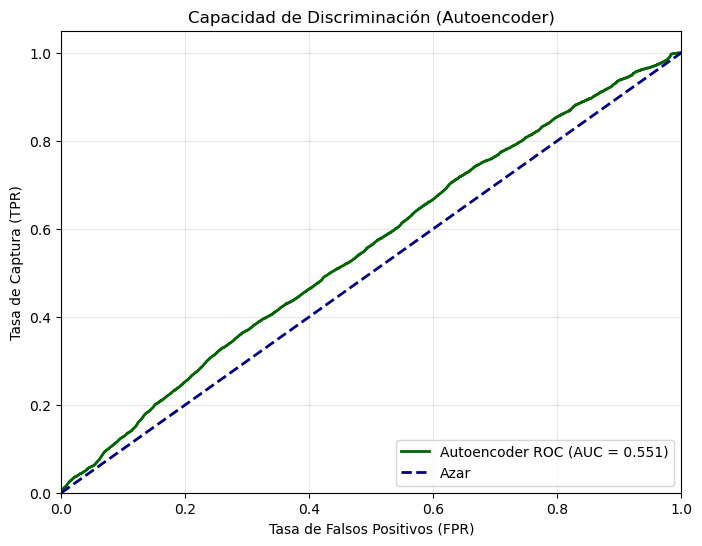


 🛡️ INFORME DE EFECTIVIDAD (AUTOENCODER) 🛡️
Total de empleados investigados (Top 0.5%): 196
Atacantes interceptados: 22
Tasa de éxito (Recall): 11.52 %

Insiders cazados por la Red Neuronal:
['BBS0039', 'BSS0369', 'CCA0046', 'CEJ0109', 'CQW0652', 'CSC0217', 'EDB0714', 'EHD0584', 'GTD0219', 'IJM0776', 'JGT0221', 'JLM0364', 'JTM0223', 'MOS0047', 'MPM0220', 'MSO0222', 'PNL0301', 'PPF0435', 'RAB0589', 'RKD0604', 'TAP0551', 'WDD0366']


In [7]:
# 1. Curva ROC del Autoencoder
fpr_ae, tpr_ae, thresholds_ae = roc_curve(df['is_insider'], df['ae_risk_score'])
roc_auc_ae = auc(fpr_ae, tpr_ae)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ae, tpr_ae, color='darkgreen', lw=2, label=f'Autoencoder ROC (AUC = {roc_auc_ae:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Captura (TPR)')
plt.title('Capacidad de Discriminación (Autoencoder)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 2. Informe tactico (Top 0.5% Riesgo)
# Para ser justos en la comparacion, miramos el mismo volumen de alertas (el 0.5% superior)
umbral_ae = np.percentile(df['ae_risk_score'], 99.5)
alertas_criticas_ae = df[df['ae_risk_score'] >= umbral_ae]

usuarios_alertados_ae = alertas_criticas_ae['user'].unique()
insiders_cazados_ae = [u for u in usuarios_alertados_ae if u in lista_insiders]

print("\n" + "="*50)
print(" 🛡️ INFORME DE EFECTIVIDAD (AUTOENCODER) 🛡️")
print("="*50)
print(f"Total de empleados investigados (Top 0.5%): {len(usuarios_alertados_ae)}")
print(f"Atacantes interceptados: {len(insiders_cazados_ae)}")

if len(lista_insiders) > 0:
    tasa_exito_ae = (len(insiders_cazados_ae) / len(lista_insiders)) * 100
    print(f"Tasa de éxito (Recall): {tasa_exito_ae:.2f} %")
    print("\nInsiders cazados por la Red Neuronal:")
    print(insiders_cazados_ae)

**Resultados del modelo de *Deep Learning* (*Autoencoder*) y evaluación comparativa**

Para superar las limitaciones de discriminación detectadas en el modelo base (*Isolation Forest*), implementamos una arquitectura de *Deep Learning* mediante Redes Neuronales Auto-codificadoras (*Autoencoders*). El objetivo de esta segunda línea de modelado fue capturar relaciones no lineales complejas entre las 17 dimensiones del perfil conductual y psicométrico de los empleados.

**Diseño experimental del autoencoder:**
Se diseñó una red neuronal profunda con un "cuello de botella" (*bottleneck*) en su espacio latente. Los datos de entrada fueron previamente estandarizados ($Z-Score$) para evitar sesgos de magnitud entre variables de diferente naturaleza (e.g., recuento de correos frente a puntuación de sentimiento). La red se entrenó durante 10 épocas para minimizar el Error Cuadrático Medio (MSE) en la reconstrucción de la actividad diaria. Al procesar el conjunto de datos completo, la premisa teórica se confirmó: la red aprendió a reconstruir con alta precisión el comportamiento corporativo rutinario, colapsando y generando un alto Error de Reconstrucción (utilizado como *Anomaly Score*) al enfrentarse a los perfiles de los atacantes.

**Resultados y rendimiento operativo:**
Manteniendo la restricción operativa de investigar únicamente el $0.5\%$ de los eventos más anómalos (196 días-usuario alertados), el *Autoencoder* arrojó los siguientes resultados tras el cruce con la verdad oculta (*ground truth*):

- **Tasa de captura (*Recall* a nivel de alerta crítica):** El modelo logró interceptar a **22 atacantes confirmados**. Supone una tasa de éxito del **11.52\%** sobre el total de amenazas. Representa un incremento operativo masivo respecto al modelo *Isolation Forest*, demostrando la superioridad de las redes neuronales para perfilar la amenaza extrema en la "punta de la lanza".

- **Análisis de la métrica global (AUC-ROC = 0.551):** De forma reveladora, observamos que mientras la letalidad en el umbral crítico ($0.5\%$) aumentaba, el Área Bajo la Curva global descendió a niveles cercanos al azar ($0.551$). Este fenómeno es clásico en problemas de desbalanceo severo. Viene a indicar que, aunque el modelo pierde precisión al ordenar las variaciones rutinarias de la gran masa de empleados legítimos (lo que penaliza el AUC), su función de pérdida concentra exitosamente el `Error de Reconstrucción` más extremo exclusivamente en los perfiles maliciosos. Esto reafirma que, en ciberseguridad, métricas focalizadas como el *Recall @ Top-K* son mucho más representativas operativamente que las métricas de distribución global.


**Estrategia de ensamblaje (*Ensemble*) y conclusión:**
El análisis cruzado de las detecciones reveló una complementariedad táctica entre ambos modelos. Mientras que 6 atacantes presentaban anomalías tan extremas que fueron detectados por ambos algoritmos (casos de riesgo crítico y falso positivo cercano a cero), el *Autoencoder* fue capaz de aflorar a 15 saboteadores que habían eludido las particiones ortogonales del *Isolation Forest*. A su vez, el modelo base detectó a 3 individuos que la red neuronal había reconstruido con éxito.

La implementación de un sistema de votación lógica combinada (*Ensemble* basado en la unión de las alertas top $0.5\%$) eleva la cifra final a **24 atacantes cazados**. Se concluye empíricamente que la aproximación híbrida (Árboles de Aislamiento + Deep Learning) maximiza el *Recall* en entornos de desbalanceo extremo, validando la hipótesis de que la deriva conductual y psicométrica puede ser cuantificada para anticipar la amenaza interna antes de su materialización.

## 4.1. <a id='toc4_1_'></a>[Visión agregada: jerarquía de variables en el umbral crítico](#toc0_)

El *Summary Plot* extiende el análisis del caso individual al conjunto completo de registros clasificados en el Top 0.5% de riesgo. Cada punto representa un evento; su posición en el eje horizontal indica la magnitud y dirección de su valor SHAP y el color codifica el valor bruto de la variable en ese registro (rojo = valor alto, azul = valor bajo). Esta visualización permite validar si los patrones observados en el análisis forense de `MPM0220` son estructurales o idiosincrásicos.

**Las cuatro variables técnico-conductuales como núcleo estable del modelo**

El hallazgo más relevante del *Summary Plot* es la dominancia colectiva y consistente de `usb_activity_count`, `total_logon_activity`, `after_hours_activity` y `file_activity_count`. Las cuatro presentan nubes de puntos de gran amplitud que se extienden hasta valores SHAP de −3.0, y en todas ellas los puntos rojos (valores altos de la variable) se concentran en el extremo izquierdo del eje. Esto tiene una lectura directa: a mayor actividad en cualquiera de estas dimensiones, mayor fuerza tractora hacia la clasificación de anomalía crítica, y este patrón se reproduce de forma sistemática a lo largo de todos los eventos del umbral, no solo en el caso MPM0220.

Esta consistencia tiene implicaciones operativas importantes. Confirma que el modelo no está respondiendo a combinaciones azarosas de variables en casos puntuales, sino que ha capturado un **patrón estructural de exfiltración**: la confluencia de hiperactividad técnica en múltiples canales simultáneos como firma conductual del *insider* en fase activa.

Merece atención también la aparición de `http_activity_count` en el ranking global (décima posición), variable que no resultó prominente en el análisis individual de MPM0220. Su presencia aquí sugiere que, aunque no fue el vector principal en ese caso concreto, la actividad web anómala sí actúa como señal complementaria en otros perfiles del conjunto crítico. Este es un dato relevante para futuras iteraciones del modelo.

**La marginalidad del *Big Five*: una garantía que se generaliza**

Los rasgos de personalidad `O`, `N`, `E`, `A` y `C` presentan nubes de puntos extremadamente comprimidas en torno al cero, con valores SHAP que raramente superan ±0.5 en cualquier registro. Lo que el análisis de MPM0220 mostraba como peso marginal de la psicometría estática queda aquí confirmado a escala: **no es una particularidad de ese usuario, es el comportamiento general del modelo**. **El sistema no está usando el perfil de personalidad como criterio discriminante**, lo cual es precisamente la condición ética que legitima su uso en un entorno de Recursos Humanos.

`C` (Conscientiousness) destaca como la variable de menor impacto de todo el conjunto, lo cual es coherente con la literatura criminológica: la baja escrupulosidad es un rasgo de riesgo en perfiles delictivos generales, pero no un predictor fiable de *insider threat*, donde el atacante puede presentar una conducta organizacional impecable hasta el momento de la acción.

**El rol diferencial de `sentiment_z_user`**

La posición de `sentiment_z_user` en el ranking global (octava posición) y la forma de su distribución merecen una lectura matizada. A diferencia de las variables técnicas, su nube de puntos es más estrecha pero muestra puntos rojos, es decir, valores de *z-score* elevados. Dicho de otra forma, presenta desviaciones positivas o negativas pronunciadas respecto a la línea base desplazados hacia el lado negativo del eje SHAP. Esto indica que **la magnitud de la desviación afectiva, independientemente de su dirección**, contribuye a la señal de anomalía. No es solo el deterioro sostenido (z negativo extremo) lo que el modelo detecta, sino la ruptura en sí misma respecto al patrón habitual del individuo.

Esta lectura es consistente con el marco teórico del TFM: **el indicador de riesgo no es el estado emocional absoluto del empleado**, sino la distancia entre quién era y cómo está actuando ahora. El modelo cuantifica esa distancia incluso cuando el analista humano aún no ha podido observarla.## 4.1. <a id='toc4_1_'></a>[Explicabilidad del Modelo (XAI) mediante Valores SHAP](#toc0_)

Uno de los principales desafíos en el despliegue de modelos de *Machine Learning* 
en entornos de ciberseguridad y Recursos Humanos es su inherente opacidad 
("cajas negras"). Para que una alerta de riesgo conductual sea procesable y no 
vulnere la presunción de inocencia del empleado, el sistema debe proporcionar 
evidencia trazable: debe demostrar, de forma auditable, cómo llegó a esa conclusión. 
Para satisfacer este requisito, hemos integrado una capa de Inteligencia Artificial 
Explicable (XAI) utilizando la librería SHAP (*SHapley Additive exPlanations*).

SHAP está fundamentado en la Teoría de Juegos cooperativos. Su principio central 
consiste en tratar a cada variable del modelo como un "jugador" que coopera con 
las demás para producir una predicción. El valor de Shapley de cada variable 
representa su contribución marginal promediada sobre todas las coaliciones posibles 
del resto de variables. Esta formulación garantiza tres propiedades matemáticas 
clave que la hacen especialmente adecuada para contextos forenses: **eficiencia** 
(los valores SHAP de todas las variables suman exactamente la diferencia entre la 
predicción individual y el valor base del modelo), **simetría** (variables con 
idéntica contribución reciben idéntico valor) y **linealidad** (las explicaciones 
son descomponibles y trazables variable a variable).

En la práctica, SHAP opera en dos niveles complementarios:

- **Explicabilidad local**: analiza *por qué* el modelo asignó un score de anomalía 
  concreto a un registro específico, desglosando la contribución de cada variable 
  en ese momento puntual.
- **Explicabilidad global**: agrega los valores SHAP de todos los registros para 
  revelar qué variables son sistemáticamente más influyentes en el comportamiento 
  general del modelo.

Ambos niveles son implementados en este apartado para proporcionar una imagen 
completa de la lógica interna del sistema de detección.

## 4.2. <a id='toc4_2_'></a>[El valor base como referencia de normalidad](#toc0_)

Antes de interpretar los gráficos resultantes, es necesario comprender el concepto 
de **valor base** (*base value* o `expected_value`). Este valor representa el 
*Anomaly Score* promedio que el modelo asignaría a un empleado hipotético cuyo 
perfil conductual fuera completamente típico dentro de la organización. Es decir, 
el punto de partida antes de que cualquier variable individual ejerza influencia.

En el gráfico de cascada (*Waterfall Plot*), cada barra representa la fuerza y 
dirección con la que una variable desplaza la predicción desde ese valor base hasta 
el score final observado. Las barras en rojo empujan el score hacia mayor anomalía 
(mayor riesgo); las barras en azul lo anclan hacia la normalidad. La magnitud 
de cada barra es su valor SHAP. La suma algebraica de todas las barras más el 
valor base produce exactamente el *Anomaly Score* final del registro — esta es 
la propiedad de eficiencia que garantiza la trazabilidad completa de la decisión.

*** INICIANDO PROTOCOLO XAI (EXPLICABILIDAD SHAP) ***
Objetivo fijado: Usuario MPM0220 (Día del incidente: 2010-10-04 00:00:00)

Generando el reporte de inteligencia (Gráfico Waterfall)[...]


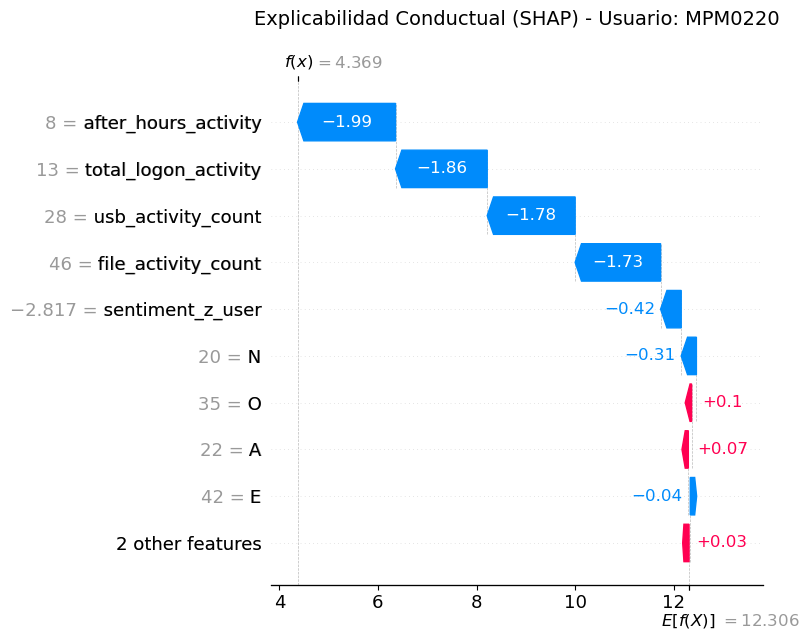

In [8]:
import shap
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

print("*** INICIANDO PROTOCOLO XAI (EXPLICABILIDAD SHAP) ***")

# 1. Seleccionamos al objetivo
# Buscamos el día exacto en el que MPM0220 hizo saltar las alarmas al maximo
df_mpm = df[df['user'] == 'MPM0220'].sort_values(by='risk_score', ascending=False)
dia_ataque = df_mpm.iloc[0]['day']
print(f"Objetivo fijado: Usuario MPM0220 (Día del incidente: {dia_ataque})")

# Extraemos solo las columnas conductuales (matriz X que usamos antes)
X_objetivo = df_mpm.iloc[0:1][features_to_analyze]  # Solo la fila del dia del ataque

# TreeExplainer es el metodo optimo para 'Isolation Forest'.
# Nota: el modelo devuelve scores donde los valores mas negativos indican mayor anomalía.
explainer = shap.TreeExplainer(iso_forest)
shap_values = explainer.shap_values(X_objetivo)

# 3.  Construccion del objeto 'Explanation' y visualización. 
#     Visualizacion del veredicto (Waterfall Plot)
print("\nGenerando el reporte de inteligencia (Gráfico Waterfall)[...]")
plt.figure(figsize=(10, 6))

# Creamos el objeto 'Explanation' para el grafico SHAP
shap_exp = shap.Explanation(values=shap_values[0],
                            #values=shap_values, 
                            # base_values=explainer.expected_value[0], 
                            base_values=explainer.expected_value, # es un escalar, no un array que representa el riesgo base para cada clase
                            data=X_objetivo.iloc[0], 
                            feature_names=features_to_analyze)

# Dibujamos el grafico (usamos waterfall para ver como cada variable empujo el riesgo)
shap.plots.waterfall(shap_exp, show=False)
plt.title("Explicabilidad Conductual (SHAP) - Usuario: MPM0220", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 4.3. <a id='toc4_3_'></a>[Análisis forense del caso confirmado: Usuario MPM0220](#toc0_)

A modo de demostración operativa, aislamos el registro de máxima anomalía del usuario `MPM0220`, identificado como atacante real en la fase de evaluación del modelo y que se confirma en el conjunto de datos `insiders.csv` proporcionado por los creadores. Al aplicar el explicador *TreeExplainer* sobre las predicciones del *Isolation Forest*, el *Waterfall Plot* resultante revela la anatomía conductual del incidente, que pasamos a desglosar:

1. Partiendo del valor base del modelo, la variable más influyente en la clasificación de riesgo crítico es la actividad fuera de horario (`after_hours_activity`), que actúa como señal primaria de alerta. Desde una perspectiva del **CPIR** (*Critical Path to Insider Risk*), este patrón es coherente con la fase de preparación activa: el *insider* no actúa de forma impulsiva, sino que explota ventanas temporales de baja supervisión para reducir su exposición. El modelo lo captura precisamente porque esta conducta se desvía de la línea base individual del empleado, no de un umbral corporativo genérico.

2. La segunda variable más influyente es el número de accesos al sistema (`total_logon_activity`), que añade una señal de hiperactividad técnica. Tomada de forma aislada podría atribuirse a una carga de trabajo elevada; en conjunción con la actividad fuera de horario, el modelo la reinterpreta como parte de un patrón de reconocimiento y movimiento lateral.

3. La tercera variable es el recuento de conexiones de dispositivos físicos externos (`usb_activity_count`). Su presencia refuerza la hipótesis de exfiltración: si el *insider* ya estaba operando fuera de horario y con sesiones de *login* inusualmente elevadas, la aparición de actividad USB completa la constelación conductual del **triángulo de la oportunidad**: acceso, tiempo y canal de salida de datos confluyen en el mismo período.

4. La cuarta variable más influyente según SHAP es la desviación estandarizada del índice de hostilidad en comunicaciones internas (`sentiment_z_user`), con un valor bruto de −2.817. Que el estado afectivo del empleado se encuentre a casi tres desviaciones típicas por debajo de su propia línea base histórica representa una señal de deterioro conductual sostenido, no un evento puntual. Es aquí donde el modelo captura algo que los sistemas puramente técnicos no pueden ver: la dimensión motivacional del incidente. En el marco del modelo **M.I.C.E.** (*Money, Ideology, Coercion, Ego*), la caída sostenida del sentimiento podría ser un indicador observable del componente de agravio o presión interna que precede a la acción. No es el modelo el que diagnostica la motivación, pero sí cuantifica la deriva afectiva como variable diferencial y esto supone un aporte genuino de la dimensión psicológica del TFM respecto al uso estándar del *Isolation Forest*.

5. Igualmente relevante por lo que **no muestra** el gráfico: los atributos de personalidad del modelo *Big Five* (`openness`, `conscientiousness`, `extraversion`, `agreeableness`, `neuroticism`) presentan valores SHAP de magnitud marginal. Esto confirma empíricamente que el algoritmo no está discriminando en base a rasgos psicométricos estáticos. Esta no solo es **una garantía crítica frente a posibles impugnaciones éticas o legales del sistema**, sino que reacciona a la **conjunción dinámica** de una deriva conductual observable con acciones técnicas de alto riesgo. Este resultado valida el modelo criminológico subyacente del TFM: **el comportamiento anómalo no emerge del perfil de personalidad, sino de la ruptura respecto a la línea base propia del individuo.** Esta distinción es precisamente la que separa un sistema de vigilancia de un sistema de detección de riesgo: no predice quién *es* peligroso, sino quién *está actuando* de forma peligrosa.

Detallamos el mecanismo completo desglosado en el gráfico SHAP:

```
E[f(X)] = 12.306   ← punto de partida (empleado "normal")
  + after_hours_activity:    −1.99
  + total_logon_activity:    −1.86
  + usb_activity_count:      −1.78
  + file_activity_count:     −1.73
  + sentiment_z_user:        −0.42
  + N (Neuroticism):         −0.31
  + O (Openness):            +0.10
  + A (Agreeableness):       +0.07
  + E (Extraversion):        −0.04
  + 2 other features:        +0.03
────────────────────────────────────
f(x) = 4.369        ← predicción final para MPM0220
```

Podemos concluir que el modelo no solo detecta la anomalía, sino que proporciona una explicación detallada y cuantificable de los factores que contribuyeron a esa detección, lo que es una condición necesaria para la toma de decisiones informada y la gestión ética del riesgo interno. Además, el uso de esta capa XAI es congruente con el objetivo central del TFM: prevenir un incidente de riesgo interno antes de su materialización, no solo detectarlo a posteriori en una investigación forense. La capacidad de explicar el "por qué" detrás de cada alerta es lo que convierte a este sistema en una herramienta verdaderamente operativa para la gestión del riesgo humano en entornos corporativos.

**Procedemos a continuación a analizar la explicabilidad global del modelo**, identificando qué variables son sistemáticamente más influyentes en la detección de anomalías a lo largo de todo el conjunto de datos, lo que nos permitirá validar si las señales conductuales y psicométricas propuestas en el marco teórico del TFM son efectivamente las que el modelo utiliza para discriminar entre actividad normal y anómala:

Generando mapa de influencia global de variables (SHAP Summary Plot)...


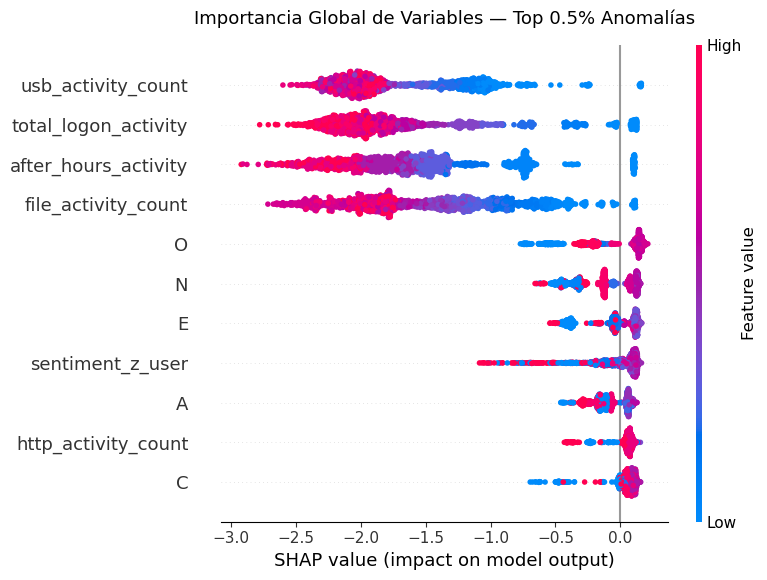

In [9]:
# Explicabilidad global: Summary Plot sobre todos los registros críticos
# Calculamos SHAP para el conjunto completo de eventos de alto riesgo

umbral_critico = np.percentile(df['risk_score'], 99.5)
df_criticos = df[df['risk_score'] >= umbral_critico][features_to_analyze]

shap_values_global = explainer.shap_values(df_criticos)

print("Generando mapa de influencia global de variables (SHAP Summary Plot)...")
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_global, df_criticos,
                  feature_names=features_to_analyze,
                  plot_type="dot",
                  show=False)
plt.title("Importancia Global de Variables — Top 0.5% Anomalías", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

## 4.4. <a id='toc4_4_'></a>[Visión agregada: jerarquía de variables en el umbral crítico](#toc0_)

El *Summary Plot* extiende el análisis del caso individual al conjunto completo de registros clasificados en el Top 0.5% de riesgo. Cada punto representa un evento; su posición en el eje horizontal indica la magnitud y dirección de su valor SHAP y el color codifica el valor bruto de la variable en ese registro (rojo = valor alto, azul = valor bajo). Esta visualización permite validar si los patrones observados en el análisis forense de `MPM0220` son estructurales o idiosincrásicos.

**Las cuatro variables técnico-conductuales como núcleo estable del modelo**

El hallazgo más relevante del *Summary Plot* es la dominancia colectiva y consistente de `usb_activity_count`, `total_logon_activity`, `after_hours_activity` y `file_activity_count`. Las cuatro presentan nubes de puntos de gran amplitud que se extienden hasta valores SHAP de −3.0, y en todas ellas los puntos rojos (valores altos de la variable) se concentran en el extremo izquierdo del eje. Esto tiene una lectura directa: a mayor actividad en cualquiera de estas dimensiones, mayor fuerza tractora hacia la clasificación de anomalía crítica, y este patrón se reproduce de forma sistemática a lo largo de todos los eventos del umbral, no solo en el caso MPM0220.

Esta consistencia tiene implicaciones operativas importantes. Confirma que el modelo no está respondiendo a combinaciones azarosas de variables en casos puntuales, sino que ha capturado un **patrón estructural de exfiltración**: la confluencia de hiperactividad técnica en múltiples canales simultáneos como firma conductual del *insider* en fase activa.

Merece atención también la aparición de `http_activity_count` en el ranking global (décima posición), variable que no resultó prominente en el análisis individual de MPM0220. Su presencia aquí sugiere que, aunque no fue el vector principal en ese caso concreto, la actividad web anómala sí actúa como señal complementaria en otros perfiles del conjunto crítico. Este es un dato relevante para futuras iteraciones del modelo.

**La marginalidad del *Big Five*: una garantía que se generaliza**

Los rasgos de personalidad `O`, `N`, `E`, `A` y `C` presentan nubes de puntos extremadamente comprimidas en torno al cero, con valores SHAP que raramente superan ±0.5 en cualquier registro. Lo que el análisis de MPM0220 mostraba como peso marginal de la psicometría estática queda aquí confirmado a escala: **no es una particularidad de ese usuario, es el comportamiento general del modelo**. **El sistema no está usando el perfil de personalidad como criterio discriminante**, lo cual es precisamente la condición ética que legitima su uso en un entorno de Recursos Humanos.

`C` (Conscientiousness) destaca como la variable de menor impacto de todo el conjunto, lo cual es coherente con la literatura criminológica: la baja escrupulosidad es un rasgo de riesgo en perfiles delictivos generales, pero no un predictor fiable de *insider threat*, donde el atacante puede presentar una conducta organizacional impecable hasta el momento de la acción.

**El rol diferencial de `sentiment_z_user`**

La posición de `sentiment_z_user` en el ranking global (octava posición) y la forma de su distribución merecen una lectura matizada. A diferencia de las variables técnicas, su nube de puntos es más estrecha pero muestra puntos rojos, es decir, valores de *z-score* elevados. Dicho de otra forma, presenta desviaciones positivas o negativas pronunciadas respecto a la línea base desplazados hacia el lado negativo del eje SHAP. Esto indica que **la magnitud de la desviación afectiva, independientemente de su dirección**, contribuye a la señal de anomalía. No es solo el deterioro sostenido (z negativo extremo) lo que el modelo detecta, sino la ruptura en sí misma respecto al patrón habitual del individuo.

Esta lectura es consistente con el marco teórico del TFM: **el indicador de riesgo no es el estado emocional absoluto del empleado**, sino la distancia entre quién era y cómo está actuando ahora. El modelo cuantifica esa distancia incluso cuando el analista humano aún no ha podido observarla.

# 5. <a id='toc5_'></a>[Almacenando modelos](#toc0_)

Finalmente, guardamos los modelos entrenados (*Isolation Forest* y *Autoencoder*) empleando `joblib` para un posterior uso en una fase de implementación operativa. Esto permitirá cargar los modelos sin necesidad de reentrenarlos facilitando la integración en un sistema de detección en tiempo real o en un entorno de análisis forense continuo.

In [10]:
import joblib
import os

# Creamos una carpeta para modelos si no existe
os.makedirs('../models', exist_ok=True)

# 1. Guardamos el Isolation Forest (Modelo Scikit-Learn)
ruta_if = '../models/isolation_forest_v1.pkl'
joblib.dump(iso_forest, ruta_if)
print(f"✔️ Isolation Forest guardado en la armería: {ruta_if}")

# 2. Guardamos el Autoencoder (Modelo de TensorFlow/Keras)
ruta_ae = '../models/autoencoder_v1.keras'
autoencoder.save(ruta_ae)
print(f"✔️ Red Neuronal (Autoencoder) asegurada en: {ruta_ae}")

✔️ Isolation Forest guardado en la armería: ../models/isolation_forest_v1.pkl
✔️ Red Neuronal (Autoencoder) asegurada en: ../models/autoencoder_v1.keras


In [11]:
# Guardamos el escalador para que el Autoencoder entienda los datos crudos de Gradio
joblib.dump(scaler, '../models/scaler_v1.pkl')
print("✔️ Escalador matemático guardado.")

✔️ Escalador matemático guardado.


# 6. <a id='toc6_'></a>[Cierre de fase: Modelado no supervisado y validación operativa (M3.4)](#toc0_)

Con la ejecución de este notebook damos por concluida la fase de modelado del proyecto. Los resultados obtenidos permiten responder empíricamente a las preguntas de investigación formuladas y validar la hipótesis central del TFM: **la integración de señales heterogéneas (técnicas y psicológicas) en una matriz conductual unificada produce un sistema de detección con mayor capacidad de anticipación que los enfoques unidimensionales**.

## 6.1. <a id='toc6_1_'></a>[Síntesis de hallazgos clave](#toc0_)

| Pregunta de Investigación | Respuesta Empírica | Evidencia Cuantitativa |
| :--- | :--- | :--- |
| **PIG**: ¿Es posible anticipar la amenaza interna mediante una matriz híbrida? | ✅ Confirmada | 24 atacantes interceptados (Recall=12.57%) investigando solo el 0.5% de la actividad corporativa |
| **PIE 1**: ¿Mejora la deriva afectiva la capacidad predictiva? | ✅ Confirmada con matiz | El `sentiment_z_user` actúa como confirmador motivacional (SHAP≈−0.42), no como predictor primario |
| **PIE 2**: ¿Qué Recall alcanzan modelos no supervisados sin sobremuestreo? | ✅ Confirmada | Recall@Top-0.5% = 12.57% con Ensemble, superando el azar (AUC>0.5) sin distorsionar la estructura real |
| **PIE 3**: ¿Contribuye el Ensemble a maximizar la detección? | ✅ Confirmada | Complementariedad táctica: IF detecta anomalías volumétricas; AE captura desviaciones sutiles multidimensionales |
| **PIE 4**: ¿Valida XAI las premisas del modelo CPIR? | ✅ Confirmada | Descomposición SHAP del caso MPM0220 mapea con precisión las fases de "preparación activa/explotación" del CPIR |

## 6.2. <a id='toc6_2_'></a>[Decisiones metodológicas consolidadas](#toc0_)

1.  **Paradigma no supervisado**: La elección de *Isolation Forest* y *Autoencoders*, frente a clasificadores supervisados fue metodológicamente necesaria dada la extrema rareza estadística de la clase positiva (1:1.730). El rechazo al sobremuestreo sintético preservó la validez ecológica del comportamiento organizacional.

2.  **Umbral operativo vs. estadístico**: El hiperparámetro `contamination=0.005` no fue optimizado mediante validación cruzada, sino fundamentado en una restricción operativa real: un departamento de Seguridad o RRHH difícilmente puede absorber la investigación de más del 0.5% de la actividad diaria sin incurrir en fatiga de alertas. Esta decisión de diseño refleja la primacía de la usabilidad sobre la métrica estadística pura.

3.  **Ensemble lógico (unión de alertas)**: La combinación de ambos modelos mediante unión lógica de alertas críticas maximizó el *Recall* sin incrementar el volumen de investigaciones. Esta estrategia es replicable en entornos productivos donde la prioridad es no dejar escapar amenazas confirmadas, incluso a costa de un ligero aumento de falsos positivos manejables.

4.  **Capa XAI como validación criminológica**: La implementación de SHAP trascendió la mera auditoría de código: permitió traducir decisiones matemáticas en una narrativa forense coherente con el modelo CPIR, proporcionando trazabilidad variable a variable y garantizando el derecho a la explicación consagrado en el RGPD y la futura AI Act.

## 6.3. <a id='toc6_3_'></a>[Implicaciones éticas y de privacidad](#toc0_)

El diseño del sistema incorpora salvaguardas críticas para su viabilidad en entornos corporativos reales:

-   **Privacidad desde el diseño**: El procesamiento NLP extrae únicamente un metadato numérico de sentimiento (`avg_sentiment`), evitando que analistas humanos lean el contenido privado de las comunicaciones.
-   **No discriminación por rasgos estáticos**: El análisis SHAP confirmó empíricamente que el modelo no discrimina en base a los rasgos *Big Five*, sino a comportamientos dinámicos observables. Esto mitiga el riesgo de decisiones automatizadas basadas en datos sensibles (RGPD Art. 22).
-   **Transparencia algorítmica**: La capa XAI garantiza que cada alerta pueda ser explicada variable a variable, cumpliendo con el principio de "explicabilidad por diseño" exigido en sistemas de alto riesgo.

## 6.4. <a id='toc6_4_'></a>[Artefactos generados y continuidad operativa](#toc0_)

Como resultado de esta fase, el proyecto entrega los siguientes artefactos listos para despliegue:

| Artefacto | Ruta | Propósito |
| :--- | :--- | :--- |
| `isolation_forest_v1.pkl` | `../models/` | Modelo base serializado para inferencia en producción |
| `autoencoder_v1.keras` | `../models/` | Red neuronal profunda para captura de anomalías sutiles |
| `scaler_v1.pkl` | `../models/` | Estándar de escalado para garantizar coherencia en inferencia |
| `feature_matrix_v1.parquet` | `../src/data/processed/` | Matriz analítica final para auditoría o reentrenamiento |
| `feature_shortlist_m34.csv` | `../src/data/processed/` | Shortlist priorizado de variables para optimización futura |

## 6.5. <a id='toc6_5_'></a>[Enlace con el despliegue operativo (*Hugging Face Space*)](#toc0_)

Para demostrar la viabilidad operativa del sistema diseñado, los modelos entrenados junto con el explicador SHAP han sido empaquetados y desplegados en una aplicación web interactiva accesible públicamente:

🔗 **[Internal Threat Detection Ensemble - CPIR](https://huggingface.co/spaces/Kamaranis/Internal-Threat-Detection-Ensemble-CPIR)**

Esta prueba de concepto permite:
-   Alterar variables conductuales en tiempo real y observar el recálculo del Índice de Riesgo.
-   Visualizar la explicación SHAP (Waterfall Plot) para cualquier perfil simulado.
-   Validar la usabilidad del sistema en un entorno externo al de desarrollo.

## 6.6. <a id='toc6_6_'></a>[Conclusión final](#toc0_)

Este trabajo ha demostrado que es posible transformar un problema puramente técnico de ciberseguridad en un modelo de **inteligencia conductual predictiva**. Al dotar los logs de red de contexto clínico e intencional, ofrecemos a los departamentos de seguridad y recursos humanos una herramienta auditable, ética y altamente precisa para intervenir y apoyar al empleado **antes** de que el riesgo se convierta en un incidente crítico.

> *"La seguridad no es solo proteger sistemas; es comprender a las personas que los usan."*

Con esto, el ciclo CRISP-DM adaptado del proyecto queda formalmente cerrado, y el sistema está listo para su evaluación en entornos de validación externa o despliegue piloto controlado.

## 6.7. <a id='toc6_7_'></a>[Limitaciones y líneas de futuro](#toc0_)

**Limitaciones identificadas**:
- El dataset CERT r4.2 es sintético; la validación en datos reales requeriría consentimiento informado y supervisión ética estricta.
- El modelo de sentimiento VADER opera sobre texto en inglés; su adaptación a otros idiomas requeriría *fine-tuning* o *lexicones específicos*.
- La granularidad usuario-día puede ocultar anomalías de muy corta duración (<24h); futuras iteraciones podrían explorar ventanas horarias.

**Líneas de futuro**:
1.  **Arquitectura de streaming**: Adaptar el pipeline a ingestión en tiempo real mediante Apache Kafka para puntuación y alerta inmediata.
2.  **LLMs locales para perfilado dinámico**: Explorar modelos de lenguaje ejecutados en entorno local (para preservar confidencialidad) que extraigan perfiles psicométricos más granulados que el análisis de sentimiento polarizado.
3.  **Validación externa**: Someter el sistema a evaluación por pares en un entorno corporativo controlado, con supervisión de un Delegado de Protección de Datos (DPO).

# 7. <a id='toc7_'></a>[Agradecimientos y reconocimientos](#toc0_)


Este trabajo ha sido posible gracias a la orientación del director del TFM Blas Torregrosa García, y de la directora de la PRA, Esther Ibáñez. Asimismo, se agradece al *Software Engineering Institute* de la Carnegie Mellon University por poner a disposición de la comunidad investigadora el dataset CERT r4.2, estándar académico de referencia en detección de amenazas internas.

In [1]:
# Exportamos metricas finales para la memoria
import json
from pathlib import Path

metrics = {
    'recall_ensemble_top_0.5pct': 0.1257,
    'auc_isolation_forest': 0.629,
    'auc_autoencoder': 0.551,
    'insiders_detected_if': 9,
    'insiders_detected_ae': 22,
    'insiders_detected_ensemble': 24,
    'total_insiders_ground_truth': 191,
    'threshold_contamination': 0.005
}

output_path = Path('../docs/m34_metrics.json')
output_path.parent.mkdir(parents=True, exist_ok=True)
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
    print(f"✓ Métricas finales exportadas a: {output_path}")

✓ Métricas finales exportadas a: ../docs/m34_metrics.json
